In [ ]:
import os
import pickle
from typing import List, Dict
from collections import defaultdict
import matplotlib.pyplot as plt

# Type alias for score distributions
ScoreDistribution = Dict[int, List[float]]

# Directory where datasets are saved
DATASETS_DIR = "datasets"


def get_scores_distribution(
    trainset,
    model,
    score_func
) -> ScoreDistribution:
    """
    Computes score distribution per class for a single trainset.

    Parameters:
        trainset: dataset yielding (input, label).
        model: pretrained/model used for scoring.
        score_func: function(model, dataset) -> List[(score, idx)].

    Returns:
        Mapping from class label to list of scores.
    """
    # Score the dataset
    scores_and_idx = score_func(model, trainset)

    # Map indices to labels
    idx_to_label = {idx: lbl for idx, (_, lbl) in enumerate(trainset)}

    # Group scores by class
    distribution: ScoreDistribution = defaultdict(list)
    for score, idx in scores_and_idx:
        label = idx_to_label.get(idx)
        if label is not None:
            distribution[label].append(score)
    return distribution


def load_and_average_distribution(
    model_name: str,
    dataset_name: str,
    scoring_method: str,
    selection_method: str,
    rate: float,
    suffixes: List[str],
    model,
    score_func
) -> ScoreDistribution:
    """
    Loads multiple condensed datasets (for given suffixes), scores each,
    and aggregates scores by class.

    Parameters:
        model_name, dataset_name, scoring_method, selection_method, rate: identifiers.
        suffixes: list of suffix strings to load.
        model: pretrained/model used for scoring.
        score_func: function(model, dataset) -> List[(score, idx)].

    Returns:
        Aggregated ScoreDistribution across all suffixes.
    """
    aggregated: ScoreDistribution = defaultdict(list)

    for suffix in suffixes:
        # Build filename
        fname = "-".join(
            str(p) for p in [model_name, dataset_name, scoring_method, selection_method, rate, suffix]
            if p is not None
        ) + ".pkl"
        path = os.path.join(DATASETS_DIR, fname)

        # Load trainset
        with open(path, 'rb') as f:
            trainset_condensed = pickle.load(f)

        # Get distribution for this set
        dist = get_scores_distribution(trainset_condensed, model, score_func)

        # Merge
        for label, scores in dist.items():
            aggregated[label].extend(scores)

    return aggregated


def plot_distribution(
    distribution: ScoreDistribution,
    title: str = None
) -> None:
    """
    Plots a boxplot for the given score distribution by class.
    """
    classes = sorted(distribution.keys())
    data = [distribution[c] for c in classes]

    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=classes, showfliers=False)
    plt.xlabel("Class")
    plt.ylabel("Score")
    if title:
        plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [9]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import random
import torch
import matplotlib.pyplot as plt
from utils.initiate import initiate_dataset, initiate_model
import numpy as np
from condensation.sort_distance1 import (
    compute_class_centroids,
    compute_class_geometric_medians,
    compute_distance_to_centroids,
    normalized_distance_sample,
    compute_normalized_distance_scores
)
# Common parameters
model_name = "resnet18"
dataset_name = "MNIST"
rate = 0.3
suffixes = ["1", "2", "3"]

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_E1_1


C:\Users\zeyud\AppData\Local\Temp\ipykernel_23476\1722961933.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


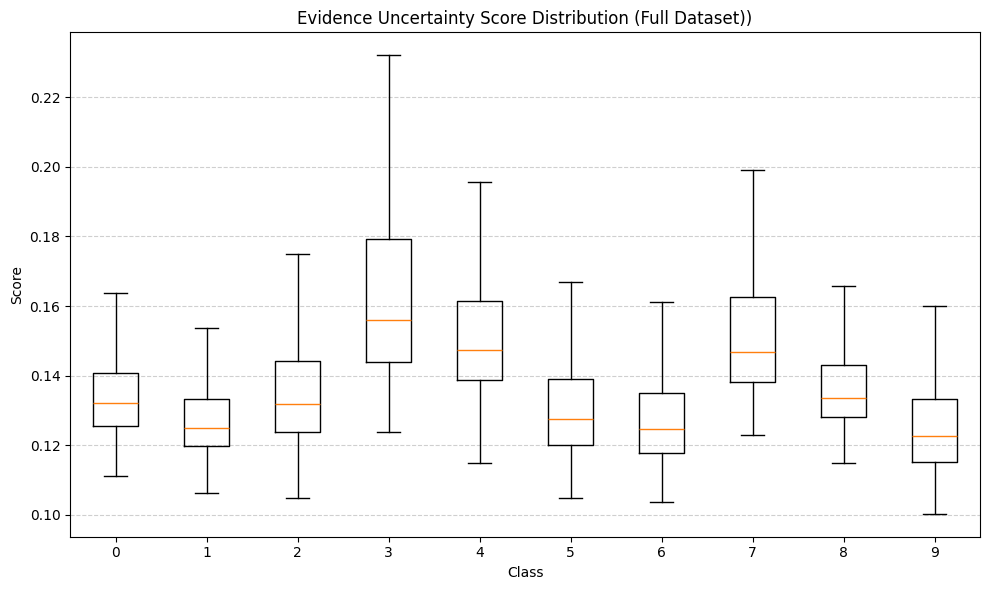

In [6]:
from condensation.sort_evidence1 import sort_by_total_evidence_dirichlet

# Initiate model and trainset
model_evidence = initiate_model(model_name, dataset_name, "models/resnet18_MNIST_E1_1")
trainset_evidence, _ = initiate_dataset(dataset_name, model_name)

# Single-run distribution
dist_evidence = get_scores_distribution(
    trainset_evidence,
    model_evidence,
    sort_by_total_evidence_dirichlet
)
plot_distribution(dist_evidence, title="Evidence Uncertainty Score Distribution (Full Dataset))")

In [ ]:
agg_evidence = load_and_average_distribution(
    model_name, dataset_name,
    "total_evidence_dirichlet", "sort_evidence1", rate, suffixes,
    model_evidence, sort_by_total_evidence_dirichlet
)
plot_distribution(agg_evidence, title="Evidence Epistemic Uncertainty (Aggregated)")

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_1


C:\Users\zeyud\AppData\Local\Temp\ipykernel_23476\1722961933.py:103: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


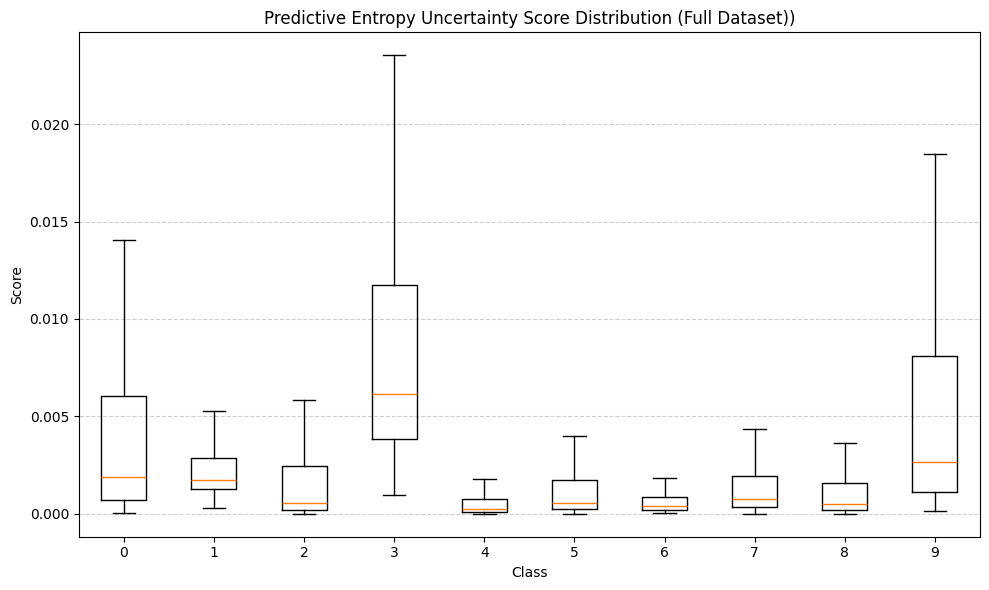

In [ ]:
from condensation.sort_entropy import sort_by_predictive_entropy, balanced_by_score

# Initiate model and trainset
model_entropy = initiate_model(model_name, dataset_name, "models/resnet18_MNIST_1")
trainset_entropy, _ = initiate_dataset(dataset_name, model_name)

# Single-run distribution
dist_entropy = get_scores_distribution(
    trainset_entropy,
    model_entropy,
    sort_by_predictive_entropy
)
plot_distribution(dist_entropy, title="Predictive Entropy Uncertainty Score Distribution (Full Dataset))")

In [ ]:
agg_entropy = load_and_average_distribution(
    model_name, dataset_name,
    "predictive_entropy", "balanced_by_score", rate, suffixes,
    model_entropy, balanced_by_score)
plot_distribution(agg_entropy, title="Predictive Entropy Uncertainty (Aggregated)")


TypeError: 'module' object is not callable. Did you mean: 'random.random(...)'?